# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

What is the shape of the DataFrames?

In [5]:
print(df_hh_income.shape)
print(df_pct_poverty.shape)
print(df_pct_completed_hs.shape)
print(df_share_race_city.shape)
print(df_fatalities.shape)

(29322, 3)
(29329, 3)
(29329, 3)
(29268, 7)
(2535, 14)


How many rows and columns do they have?

In [6]:
print(f"Rows: {df_hh_income.shape[0]}, Columns: {df_hh_income.shape[1]}")
print(f"Rows: {df_pct_poverty.shape[0]}, Columns: {df_pct_poverty.shape[1]}")
print(f"Rows: {df_pct_completed_hs.shape[0]}, Columns: {df_pct_completed_hs.shape[1]}")
print(f"Rows: {df_share_race_city.shape[0]}, Columns: {df_share_race_city.shape[1]}")
print(f"Rows: {df_fatalities.shape[0]}, Columns: {df_fatalities.shape[1]}")

Rows: 29322, Columns: 3
Rows: 29329, Columns: 3
Rows: 29329, Columns: 3
Rows: 29268, Columns: 7
Rows: 2535, Columns: 14


What are the column names?

In [7]:
print("df_hh_income:")
print(" / ".join(df_hh_income.columns.values))
print("\n")

print("df_pct_poverty:")
print(" / ".join(df_pct_poverty.columns.values))
print("\n")

print("df_pct_completed_hs:")
print(" / ".join(df_pct_completed_hs.columns.values))
print("\n")

print("df_share_race_city:")
print(" / ".join(df_share_race_city.columns.values))
print("\n")

print("df_fatalities:")
print(" / ".join(df_fatalities.columns.values))
print("\n")

df_hh_income:
Geographic Area / City / Median Income


df_pct_poverty:
Geographic Area / City / poverty_rate


df_pct_completed_hs:
Geographic Area / City / percent_completed_hs


df_share_race_city:
Geographic area / City / share_white / share_black / share_native_american / share_asian / share_hispanic


df_fatalities:
id / name / date / manner_of_death / armed / age / gender / race / city / state / signs_of_mental_illness / threat_level / flee / body_camera




Are there any NaN values or duplicates?

In [8]:
print("df_hh_income:")
print(f"Has NaN: {df_hh_income.isna().values.any()}")
print(f"Has duplicates: {df_hh_income.duplicated().values.any()}")
print("\n")

print("df_pct_poverty:")
print(f"Has NaN: {df_pct_poverty.isna().values.any()}")
print(f"Has duplicates: {df_pct_poverty.duplicated().values.any()}")
print("\n")

print("df_pct_completed_hs:")
print(f"Has NaN: {df_pct_completed_hs.isna().values.any()}")
print(f"Has duplicates: {df_pct_completed_hs.duplicated().values.any()}")
print("\n")

print("df_share_race_city:")
print(f"Has NaN: {df_share_race_city.isna().values.any()}")
print(f"Has duplicates: {df_share_race_city.duplicated().values.any()}")
print("\n")

print("df_fatalities:")
print(f"Has NaN: {df_fatalities.isna().values.any()}")
print(f"Has duplicates: {df_fatalities.duplicated().values.any()}")
print("\n")

df_hh_income:
Has NaN: True
Has duplicates: False


df_pct_poverty:
Has NaN: False
Has duplicates: False


df_pct_completed_hs:
Has NaN: False
Has duplicates: False


df_share_race_city:
Has NaN: False
Has duplicates: False


df_fatalities:
Has NaN: True
Has duplicates: False




## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

Replacing Missing values in df_fatalities:

In [9]:
df_fatalities.fillna({"armed": "undetermined"}, inplace=True)
df_fatalities.fillna({"age": 0}, inplace=True)
df_fatalities.fillna({"race": "O"}, inplace=True)
df_fatalities.fillna({"flee": "Unknown"}, inplace=True)

Replacing Missing values in df_hh_income:

In [10]:
df_hh_income.fillna({"Median Income": 0}, inplace=True)

Rename race column values in df_fatalities:

In [11]:
df_fatalities.race = df_fatalities.race.replace({"A": "Asian", "B": "Black", "H": "Hispanic", "N": "Native American", "O": "Unknown", "W": "White"})

Change df_shape_race_city column names:

In [12]:
df_share_race_city = df_share_race_city.rename(columns={"share_white": "White", "share_black": "Black", "share_native_american": "Native American", "share_asian": "Asian", "share_hispanic": "Hispanic"})

Rename gender column values in df_fatalities:

In [13]:
df_fatalities.gender = df_fatalities.gender.replace({"M": "Men", "F": "Women"})

Convert dates to datetime:

In [14]:
df_fatalities.date = pd.to_datetime(df_fatalities.date, format="%d/%m/%y")

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

Convert poverty_rate to numeric:

In [15]:
df_pct_poverty.poverty_rate = df_pct_poverty.poverty_rate.replace({"-": "0"})
df_pct_poverty.poverty_rate = pd.to_numeric(df_pct_poverty.poverty_rate)

In [16]:
df_poverty_by_state = df_pct_poverty.groupby("Geographic Area", as_index=False).agg({"poverty_rate": pd.Series.mean})
df_poverty_by_state.sort_values("poverty_rate", ascending=False, inplace=True)

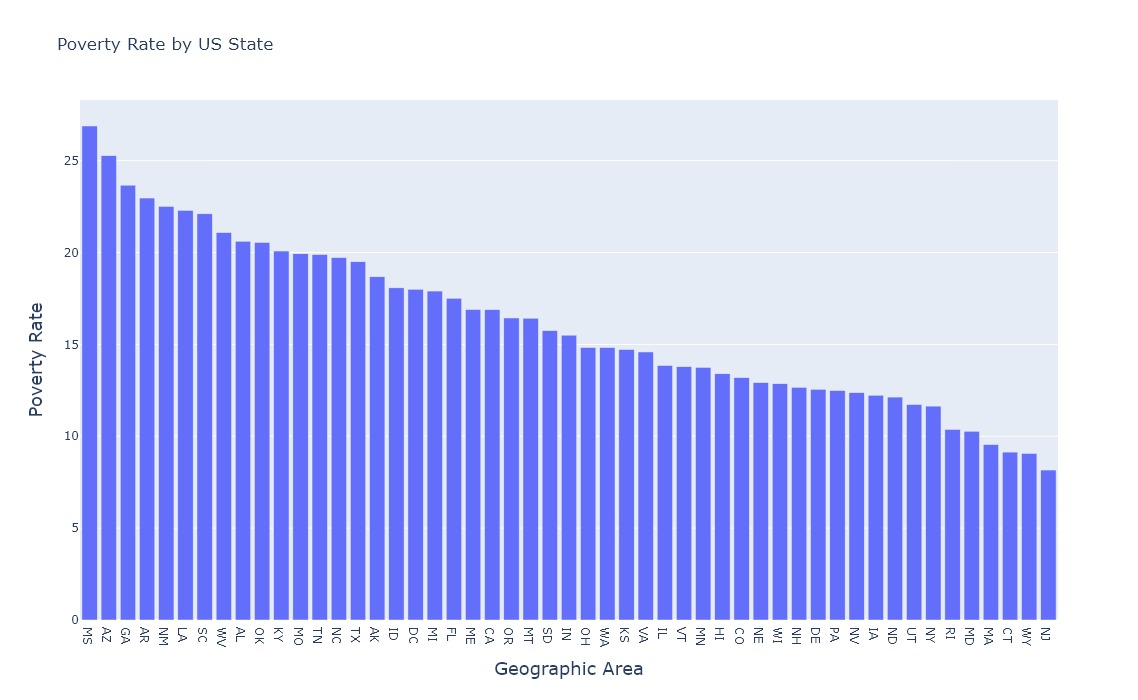

In [17]:
fig = px.bar(
    df_poverty_by_state,
    x="Geographic Area",
    y="poverty_rate",
    height=700,
    width=1000,
    title="Poverty Rate by US State"
)
fig.update_layout(
    yaxis_title="Poverty Rate",
    xaxis_title_font_size = 18,
    yaxis_title_font_size = 18,
)
fig.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

Convert percent_completed_hs to numeric:

In [18]:
df_pct_completed_hs.percent_completed_hs = df_pct_completed_hs.percent_completed_hs.replace({"-": "0"})
df_pct_completed_hs.percent_completed_hs = pd.to_numeric(df_pct_completed_hs.percent_completed_hs)

Group df_pct_completed_hs by US State:

In [19]:
df_completed_hs_by_state= df_pct_completed_hs.groupby("Geographic Area", as_index=False).mean("percent_completed_hs")
df_completed_hs_by_state.sort_values("percent_completed_hs", inplace=True)

In [20]:
fig = px.bar(
    df_completed_hs_by_state,
    x="Geographic Area",
    y="percent_completed_hs",
    height=700,
    width=1000,
    title="High School Graduation Rate by US State"
)
fig.update_layout(
    yaxis_title="High School Graduation Rate",
    xaxis_title_font_size = 18,
    yaxis_title_font_size = 18,
)
fig.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

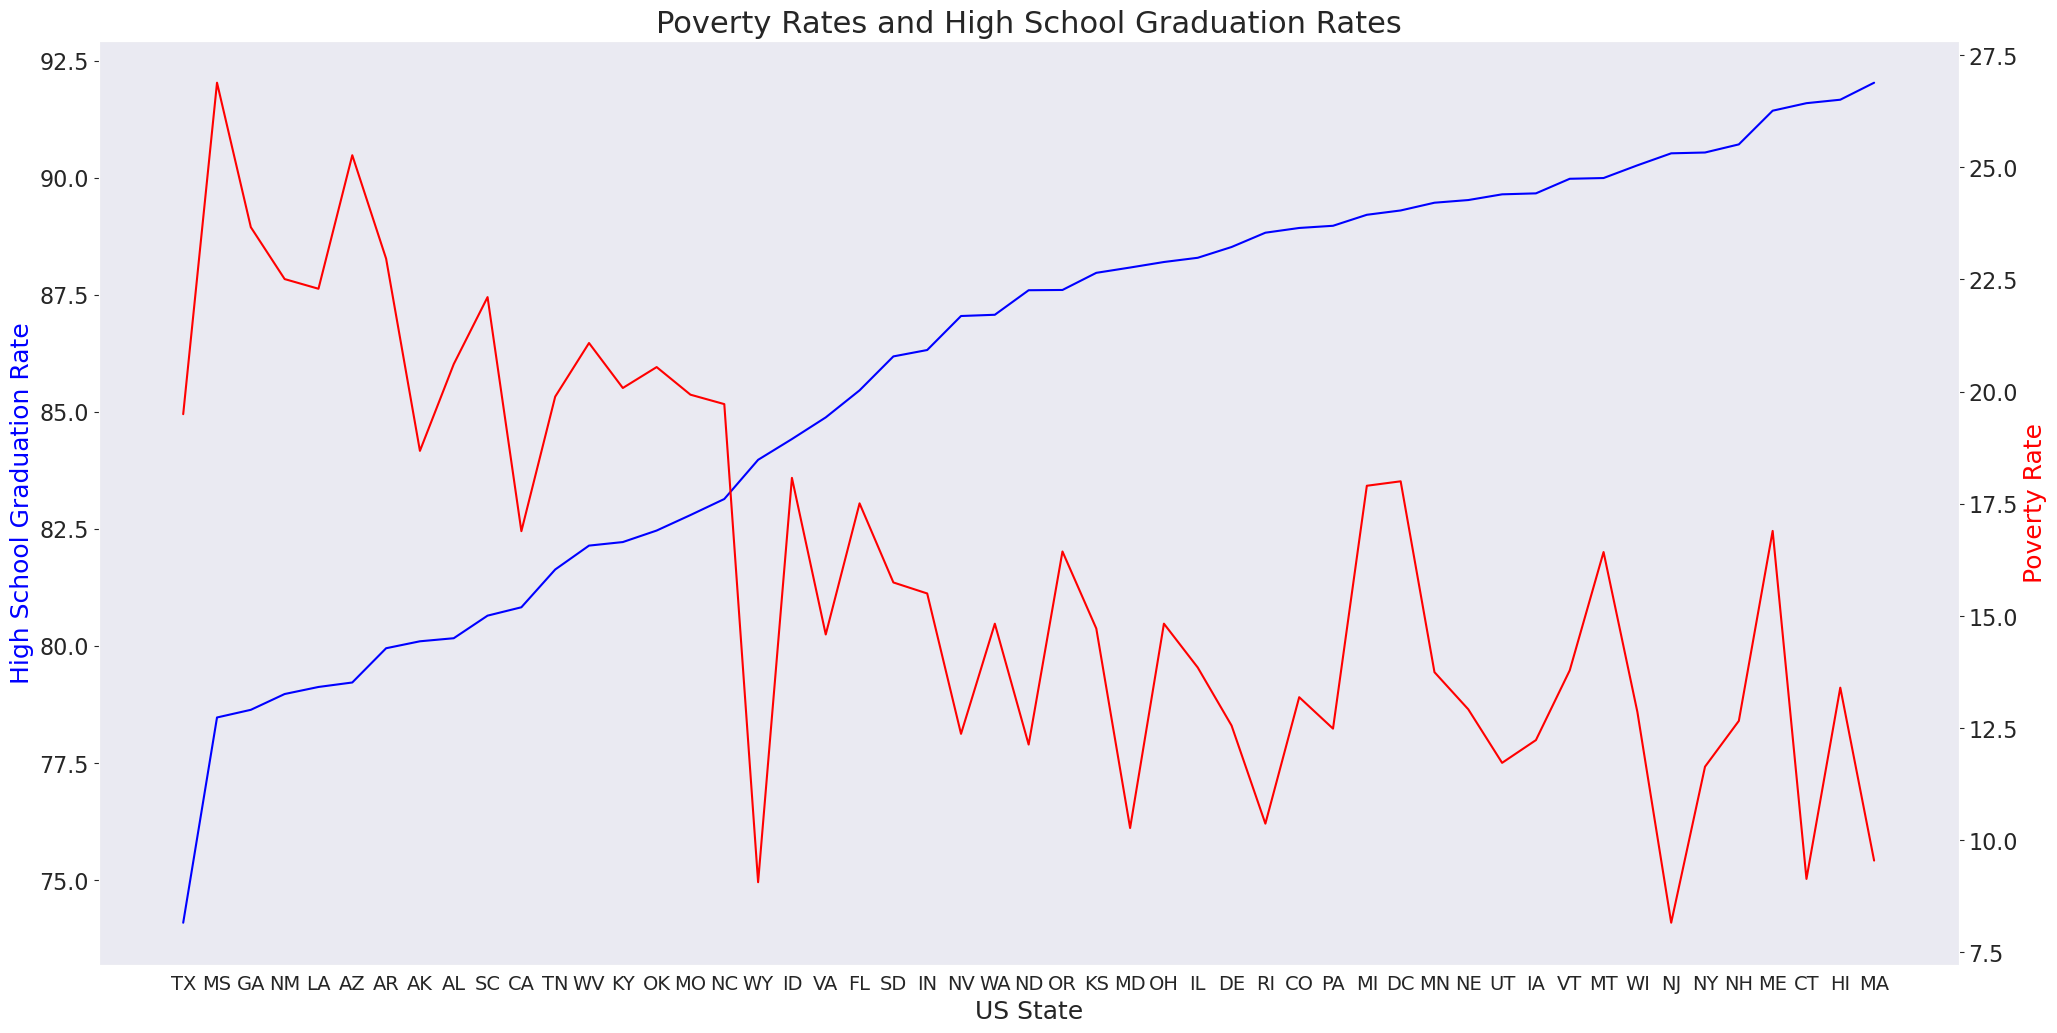

In [21]:
with sns.axes_style("dark"):
    fig, ax = plt.subplots(figsize=(24, 12)) # Setting figure size
    ax2 = ax.twinx() # Adding second index
    plt.title("Poverty Rates and High School Graduation Rates", fontsize=22) # Setting title
    ax.set_ylabel("High School Graduation Rate", color="blue", fontsize=18)
    # Configuring Axes labels
    ax2.set_ylabel("Poverty Rate", color="red", fontsize=18)
    ax.set_xlabel("US State", fontsize=18)
    # Configuring Axis ticks
    ax.tick_params(axis="y", labelsize=16)
    ax.tick_params(axis="x", labelsize=14)
    ax2.tick_params(axis="y", labelsize=16)
    # Ploting data
    sns.lineplot(x=df_completed_hs_by_state["Geographic Area"], y=df_completed_hs_by_state["percent_completed_hs"], ax=ax, color="blue")
    sns.lineplot(x=df_poverty_by_state["Geographic Area"], y=df_poverty_by_state["poverty_rate"], ax=ax2, color="red")
    
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

In [22]:
poverty_hs_relation = pd.merge(df_completed_hs_by_state, df_poverty_by_state)

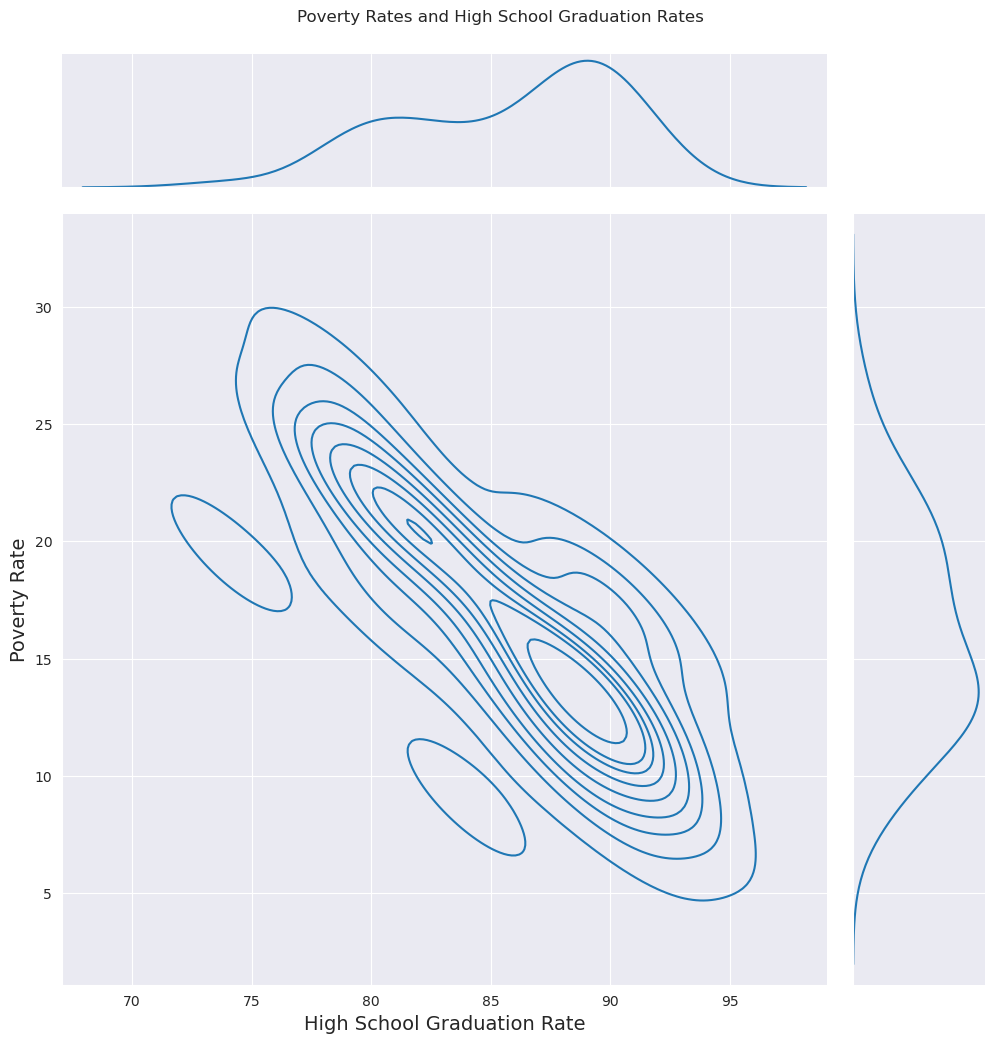

In [23]:
with sns.axes_style("darkgrid"):
    g = sns.jointplot(
        data=poverty_hs_relation, 
        x="percent_completed_hs", 
        y="poverty_rate",
        kind="kde",
        height=10
    )
    g.fig.suptitle('Poverty Rates and High School Graduation Rates', y=1.03)
    plt.xlabel("High School Graduation Rate", fontsize=14)
    plt.ylabel("Poverty Rate", fontsize=14)
plt.show()

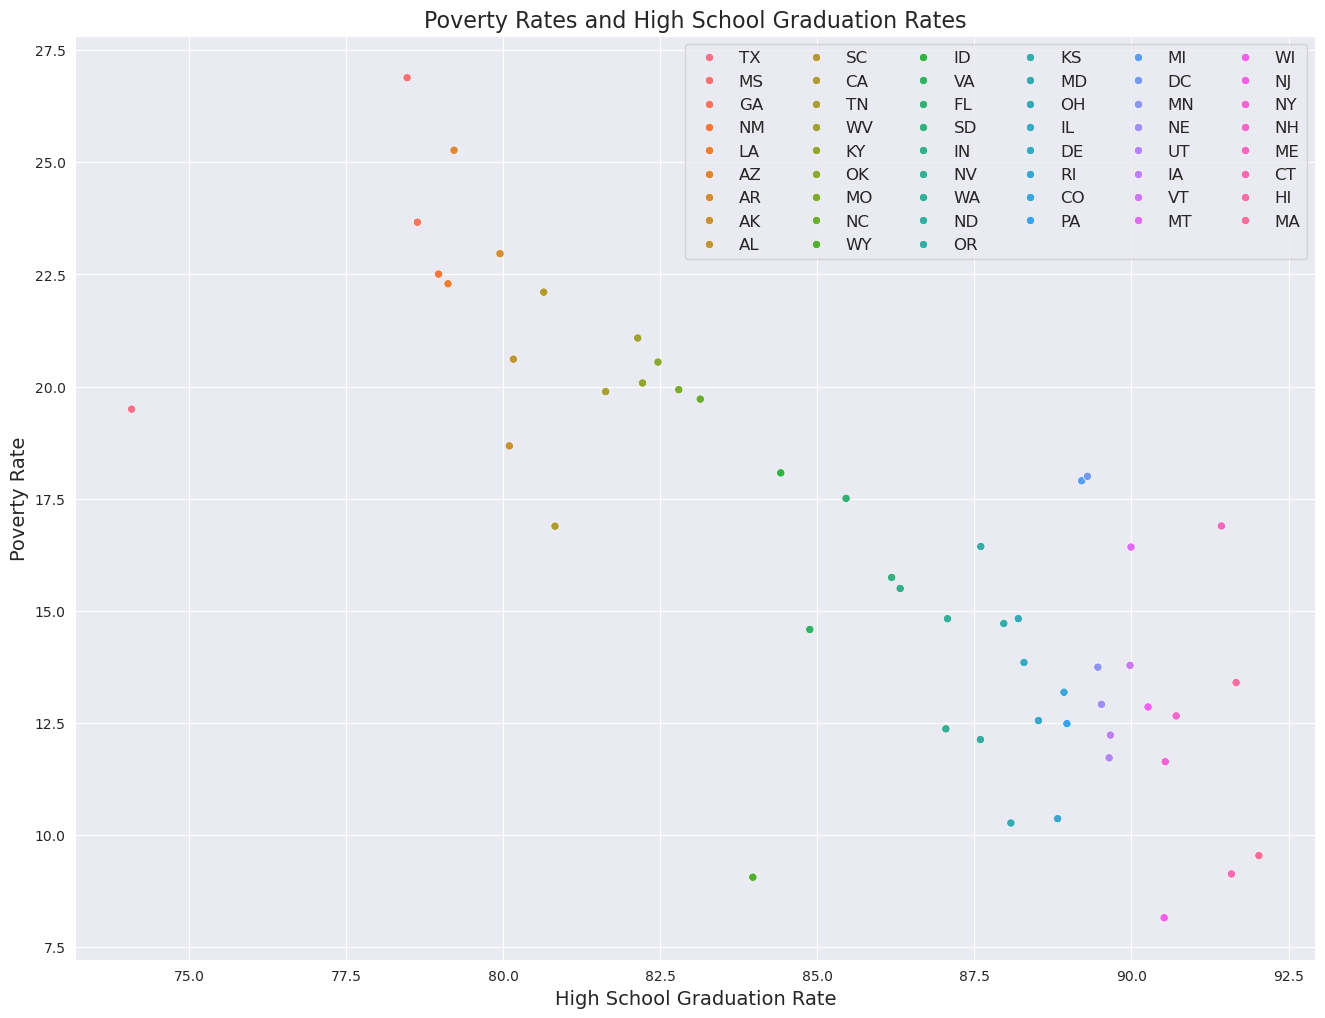

In [24]:
with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(16, 12))
    sns.scatterplot(
    data=poverty_hs_relation,
        x="percent_completed_hs",
        y="poverty_rate",
        hue="Geographic Area",
    )
    plt.legend(fontsize=12, loc="upper right", ncol=6)
    plt.title('Poverty Rates and High School Graduation Rates', fontsize=16)
    plt.xlabel("High School Graduation Rate", fontsize=14)
    plt.ylabel("Poverty Rate", fontsize=14)
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

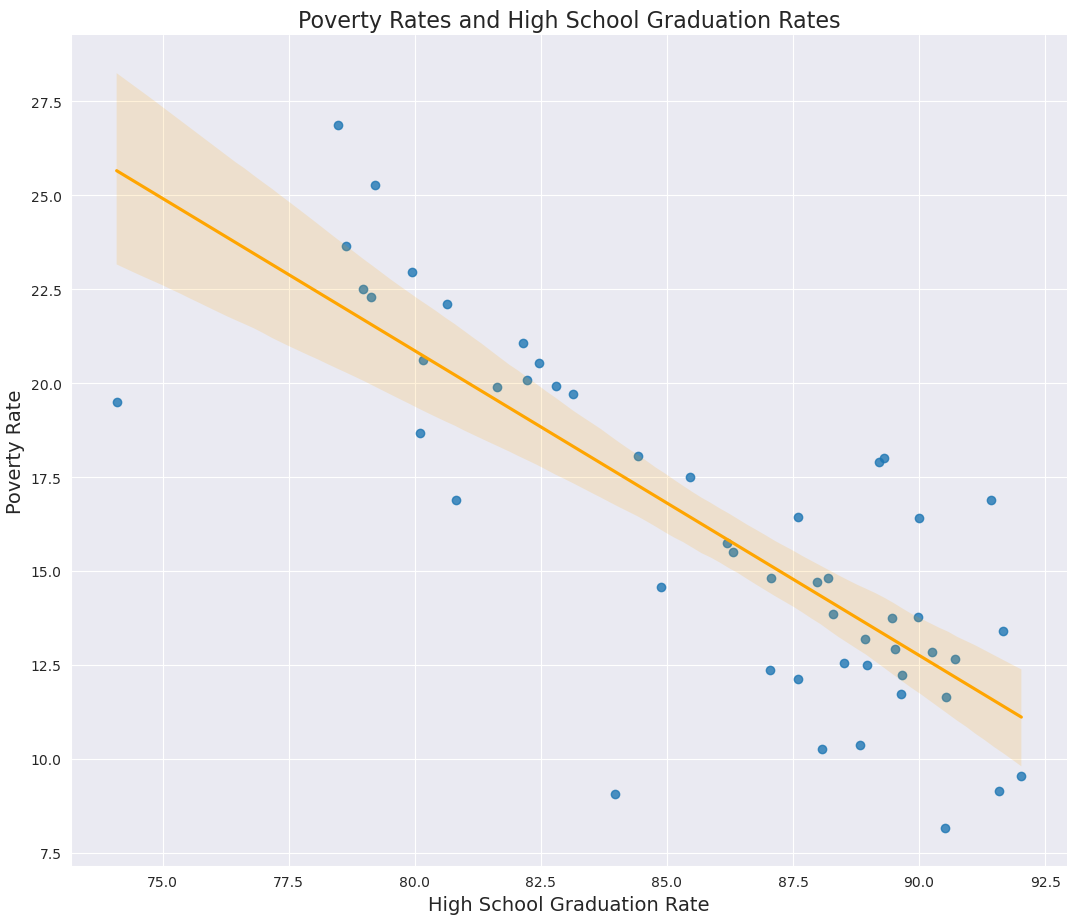

In [25]:
with sns.axes_style("darkgrid"):
    sns.lmplot(data=poverty_hs_relation, x="percent_completed_hs", y="poverty_rate", height=9, aspect=1.2, line_kws={"color": "orange"})
    plt.title('Poverty Rates and High School Graduation Rates', fontsize=16)
    plt.xlabel("High School Graduation Rate", fontsize=14)
    plt.ylabel("Poverty Rate", fontsize=14)

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [26]:
df_shares = df_share_race_city.drop(columns="City")
df_shares = df_shares.replace({"(X)": 0})
for column in df_shares.columns[1:]:
    df_shares[column] = pd.to_numeric(df_shares[column])

In [27]:
df_shares_by_state = df_shares.groupby("Geographic area").mean()
df_shares_by_state.reset_index(inplace=True)

In [28]:
fig = px.bar(
    df_shares_by_state,
    x="Geographic area",
    y=df_shares_by_state.columns[1:],
    height=900,width=1100,
    title="Racial Makeup of Each US State",
)

fig.update_layout(
    title_font_size=24,
    xaxis_title = "US State",
    xaxis_title_font_size = 18,
    yaxis_title = "Percent",
    yaxis_title_font_size = 18,
    legend=dict(title_text="Share"),
)
fig.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [29]:
df_fatalities_by_race = pd.DataFrame(df_fatalities.race.value_counts()).reset_index()

In [30]:
fig = px.pie(
    df_fatalities_by_race, 
    names="race", 
    values="count", 
    title="People Killed by Race",
)
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [31]:
df_fatalities_by_gender = pd.DataFrame(df_fatalities.gender.value_counts()).reset_index()

In [32]:
fig = px.pie(
    df_fatalities_by_gender, 
    names="gender", 
    values="count", 
    title="Total Number of Deaths of Men and Women"
)
fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [33]:
df_fatalities_by_age_by_manner = df_fatalities[df_fatalities.age > 0].groupby(["manner_of_death", "age"], as_index=False).size()

In [34]:
fig = px.box(
    data_frame=df_fatalities_by_age_by_manner,
    y="age",
    x="manner_of_death",
    color="manner_of_death",
    title="Age and Manner of Death",
    height=700
)
fig.update_layout(
    title_font_size=24,
    xaxis_title = "Manner of Death",
    xaxis_title_font_size = 18,
    yaxis_title = "Age",
    yaxis_title_font_size = 18,
    legend=dict(title_text="Manner of Death"),
)
fig.show()

In [35]:
fig = px.box(
    data_frame=df_fatalities[df_fatalities.age > 0].groupby(["manner_of_death", "age", "gender"], as_index=False).size(),
    y="age",
    x="manner_of_death",
    color="gender",
    title="Age and Manner of Death by Gender",
    height=700
)
fig.update_layout(
    title_font_size=24,
    xaxis_title = "Gender",
    xaxis_title_font_size = 18,
    yaxis_title = "Age",
    yaxis_title_font_size = 18,
    legend=dict(title_text="Manner of Death"),
)
fig.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [36]:
pct_unarmed = round(df_fatalities.armed.value_counts()["unarmed"]  * 100 / df_fatalities.armed.value_counts().sum(), 2)
print(f"{pct_unarmed}% of people killed by the police were unarmed.")

6.75% of people killed by the police were unarmed.


In [37]:
fig = px.bar(
    data_frame=pd.DataFrame(df_fatalities.armed.value_counts()).reset_index(),
    x="armed",
    y="count",
    log_y=True,
    height=700,
    width=1100,
    color_continuous_scale="Viridis",
    color="count",
    title="Were People Armed?"
)

fig.update_layout(
    title_font_size=24,
    xaxis_title = "Weapon",
    yaxis_title = "Count",
    xaxis_title_font_size = 18,
    yaxis_title_font_size = 18,
    )

fig.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [38]:
pct_under_25 = round(df_fatalities[df_fatalities.age < 25].shape[0] * 100 / df_fatalities.shape[0], 2)
print(f"{pct_under_25}% of people killed by the police were under 25 years old.")

20.79% of people killed by the police were under 25 years old.


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

In [39]:
df_fatalities_by_age = df_fatalities[df_fatalities.age > 0].groupby("age", as_index=False).size()

In [40]:
fig = px.histogram(
    data_frame=df_fatalities_by_age,
    x="age",
    y="size",
    height=700,
    log_y=True,
    title="How Old Were the People Killed?",
    histnorm="density"
)

fig.update_layout(bargap=0.1)

fig.update_layout(
    title_font_size=24,
    xaxis_title = "Age",
    yaxis_title = "Count",
    xaxis_title_font_size = 18,
    yaxis_title_font_size = 18,
    )

fig.show()

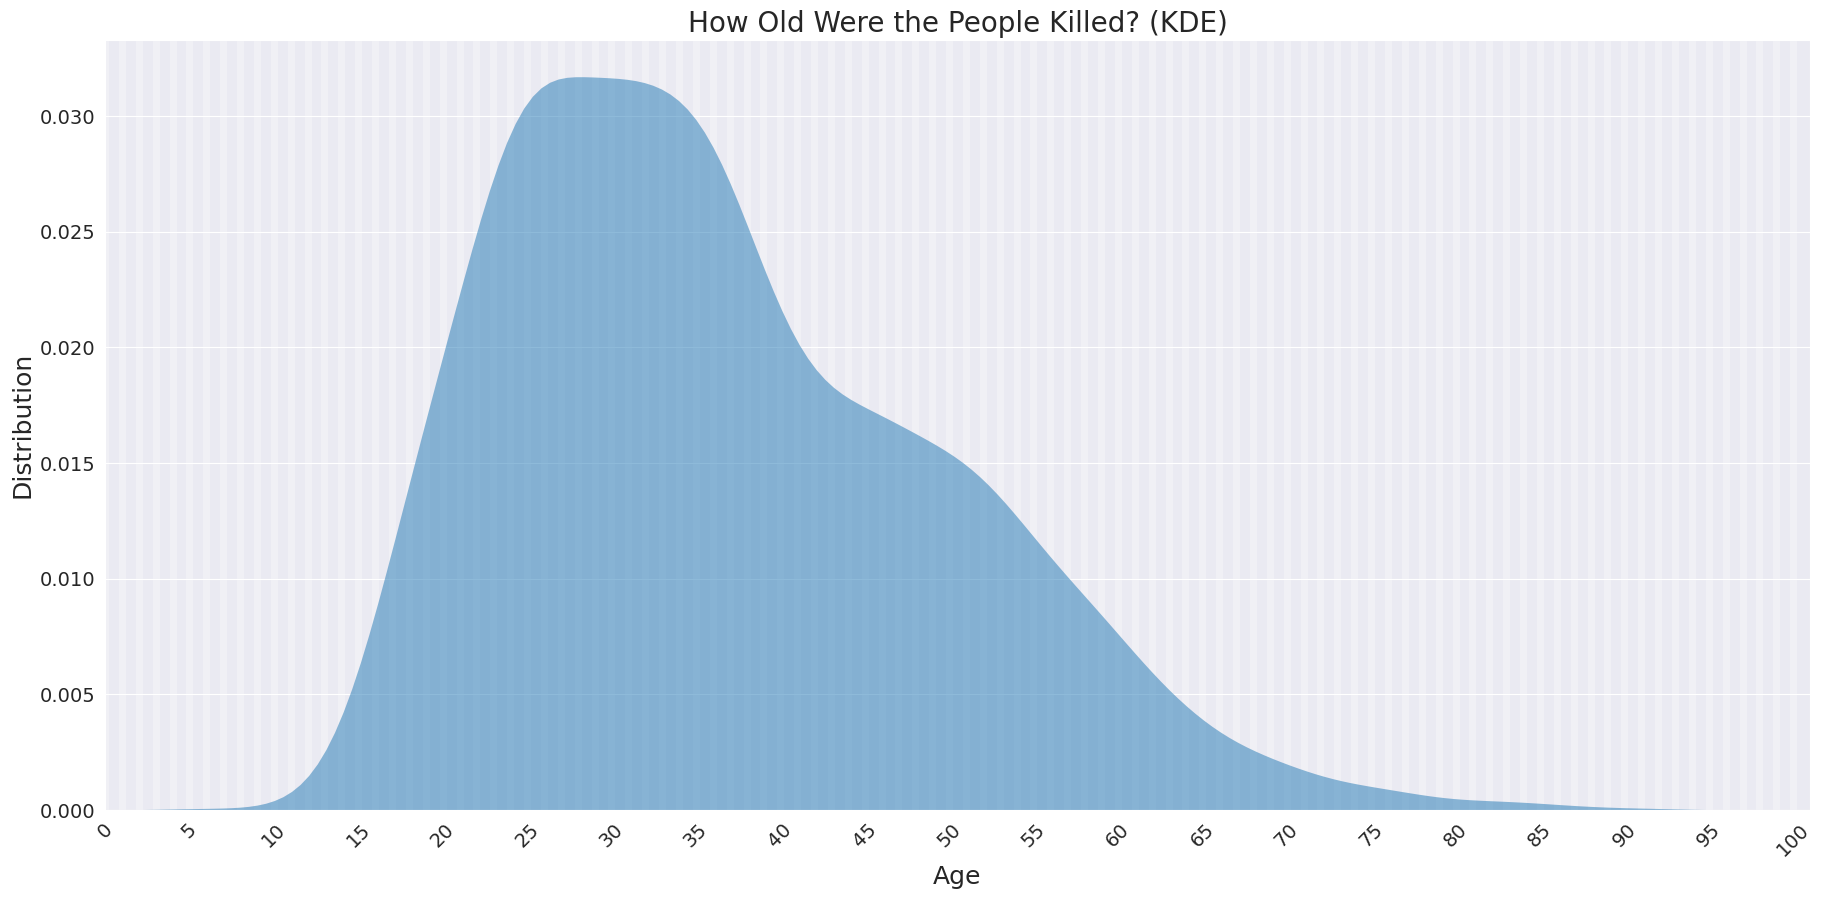

In [41]:
with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(22, 10))
    sns.kdeplot(data=df_fatalities[df_fatalities.age > 0], x="age", fill=True, common_norm=False,
   alpha=.5, linewidth=0)
    plt.title("How Old Were the People Killed? (KDE)", fontsize=20)
    plt.xlim(0, 101)
    labels = [str(i) if i % 5 == 0 else '' for i in range(0, 101)]
    plt.xticks(range(0, 101, 1), labels, rotation=45, fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True, axis="x", alpha=0.3, linewidth=5, c="white")
    plt.xlabel("Age", fontsize=18)
    plt.ylabel("Distribution", fontsize=18)

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

In [42]:
df_fatalities_by_age_by_race = df_fatalities[df_fatalities.age > 0].groupby(["age", "race"], as_index=False).size()
df_fatalities_by_age_by_race = pd.pivot(df_fatalities_by_age_by_race, index="age", columns="race", values="size").fillna(value=0).reset_index()

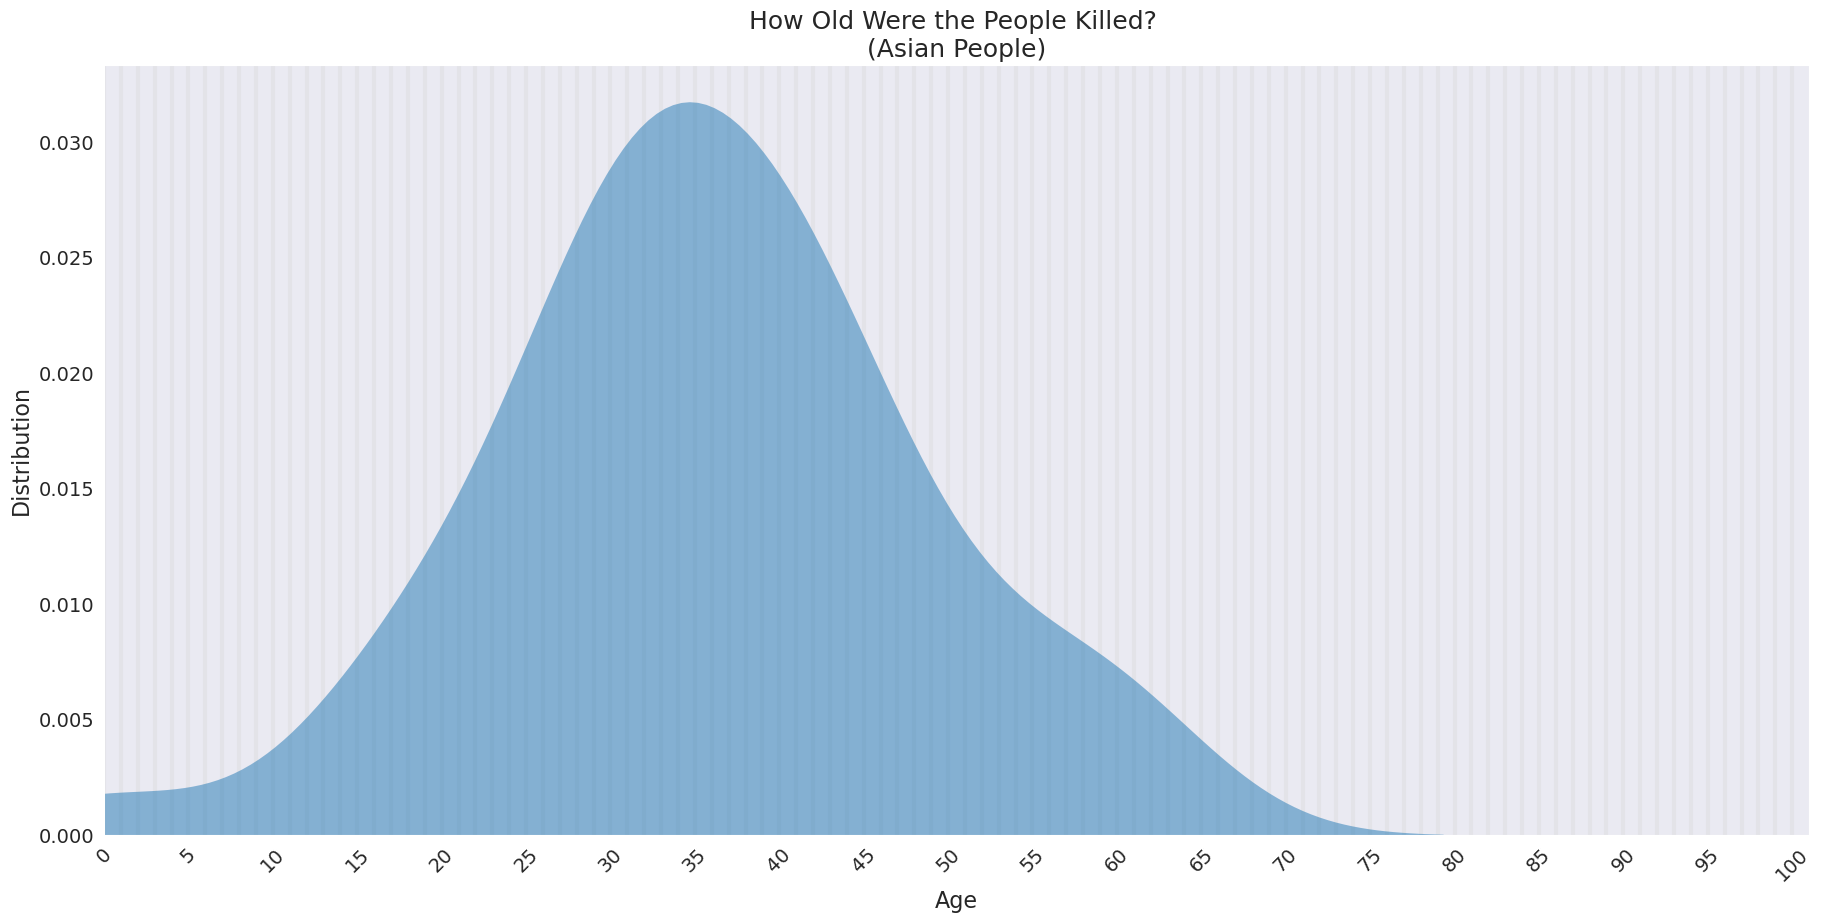

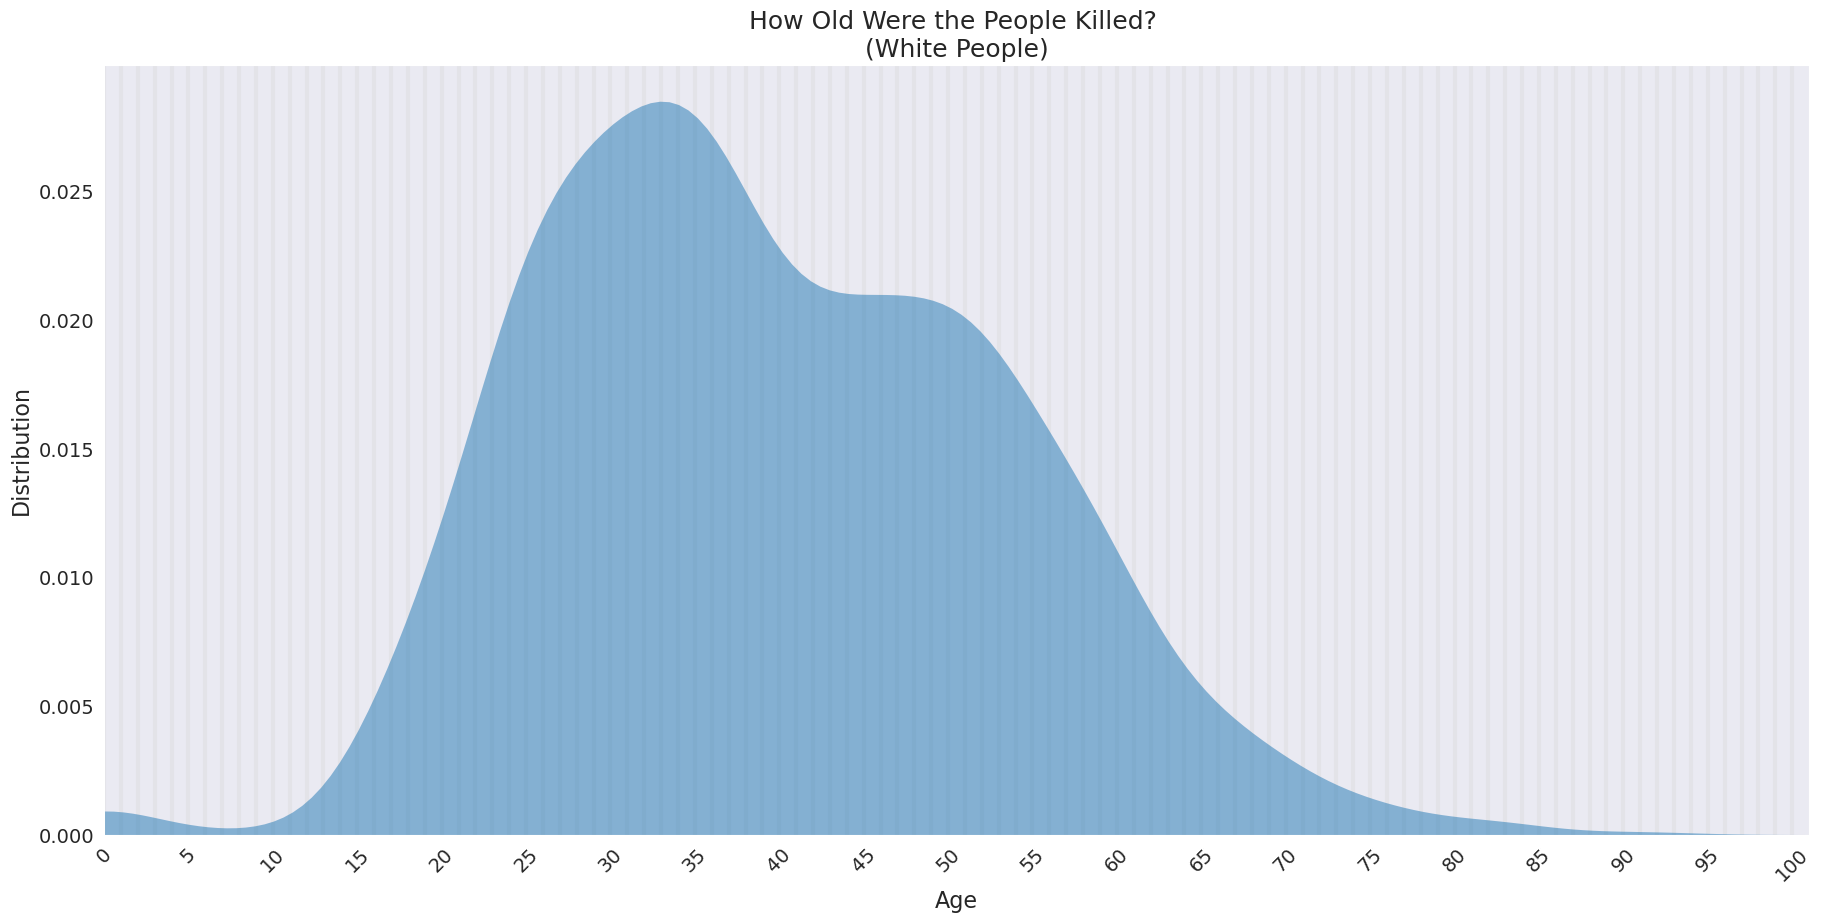

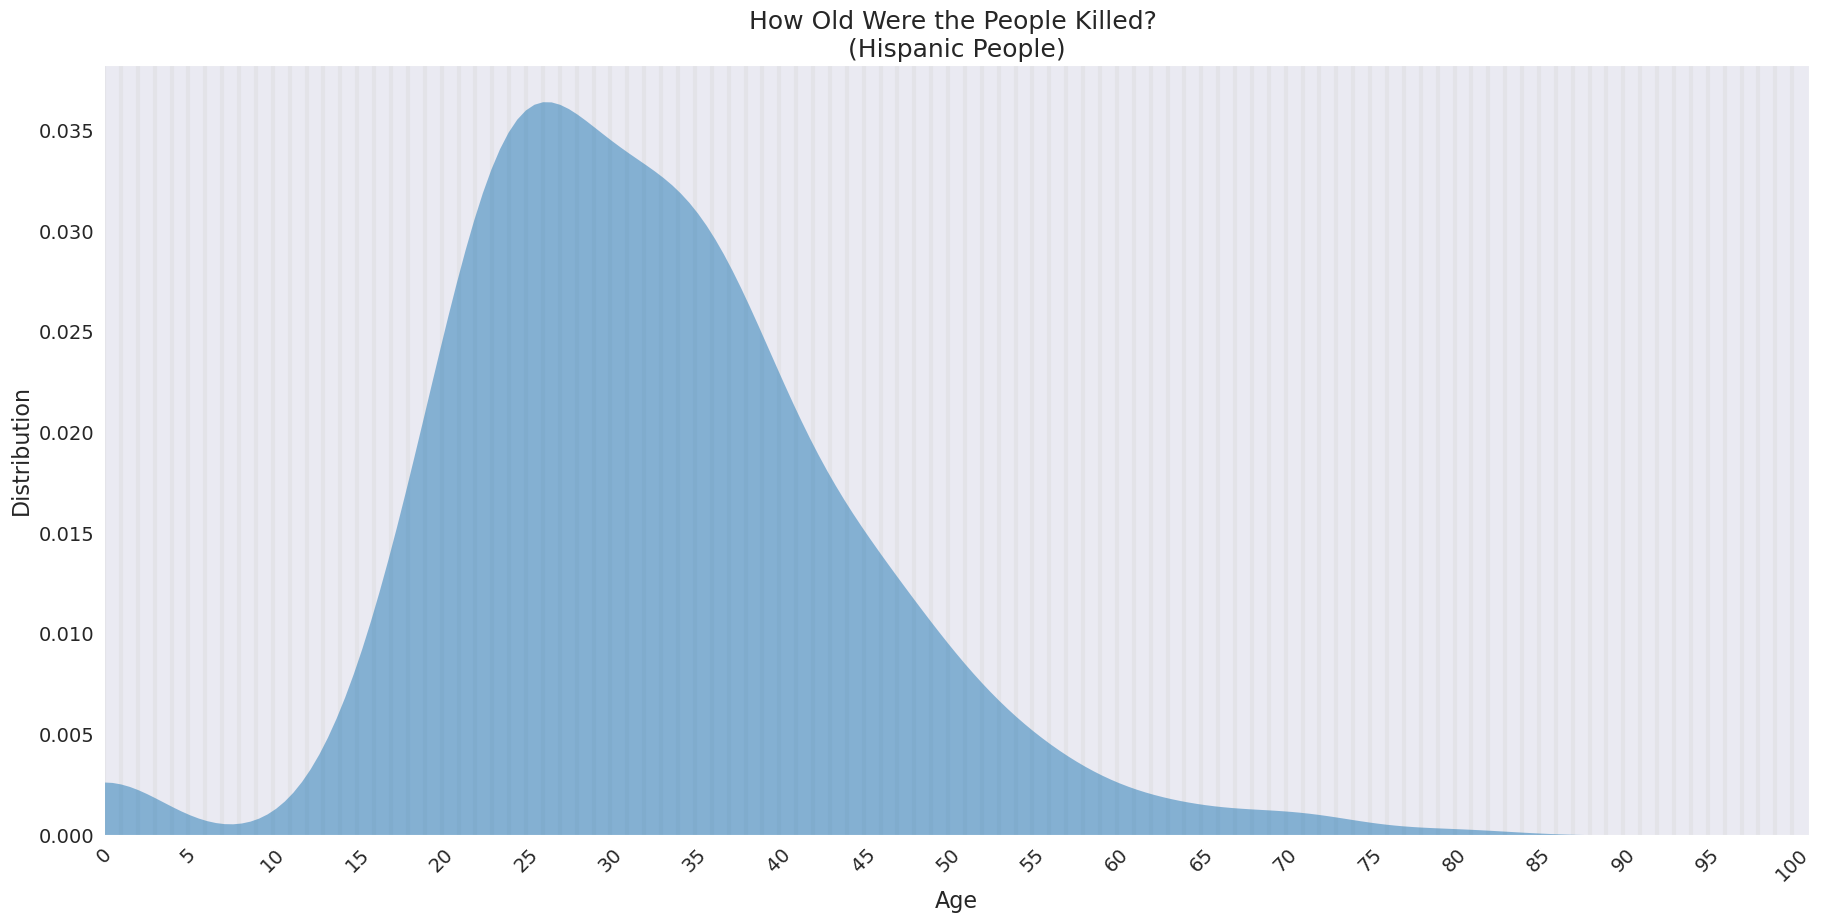

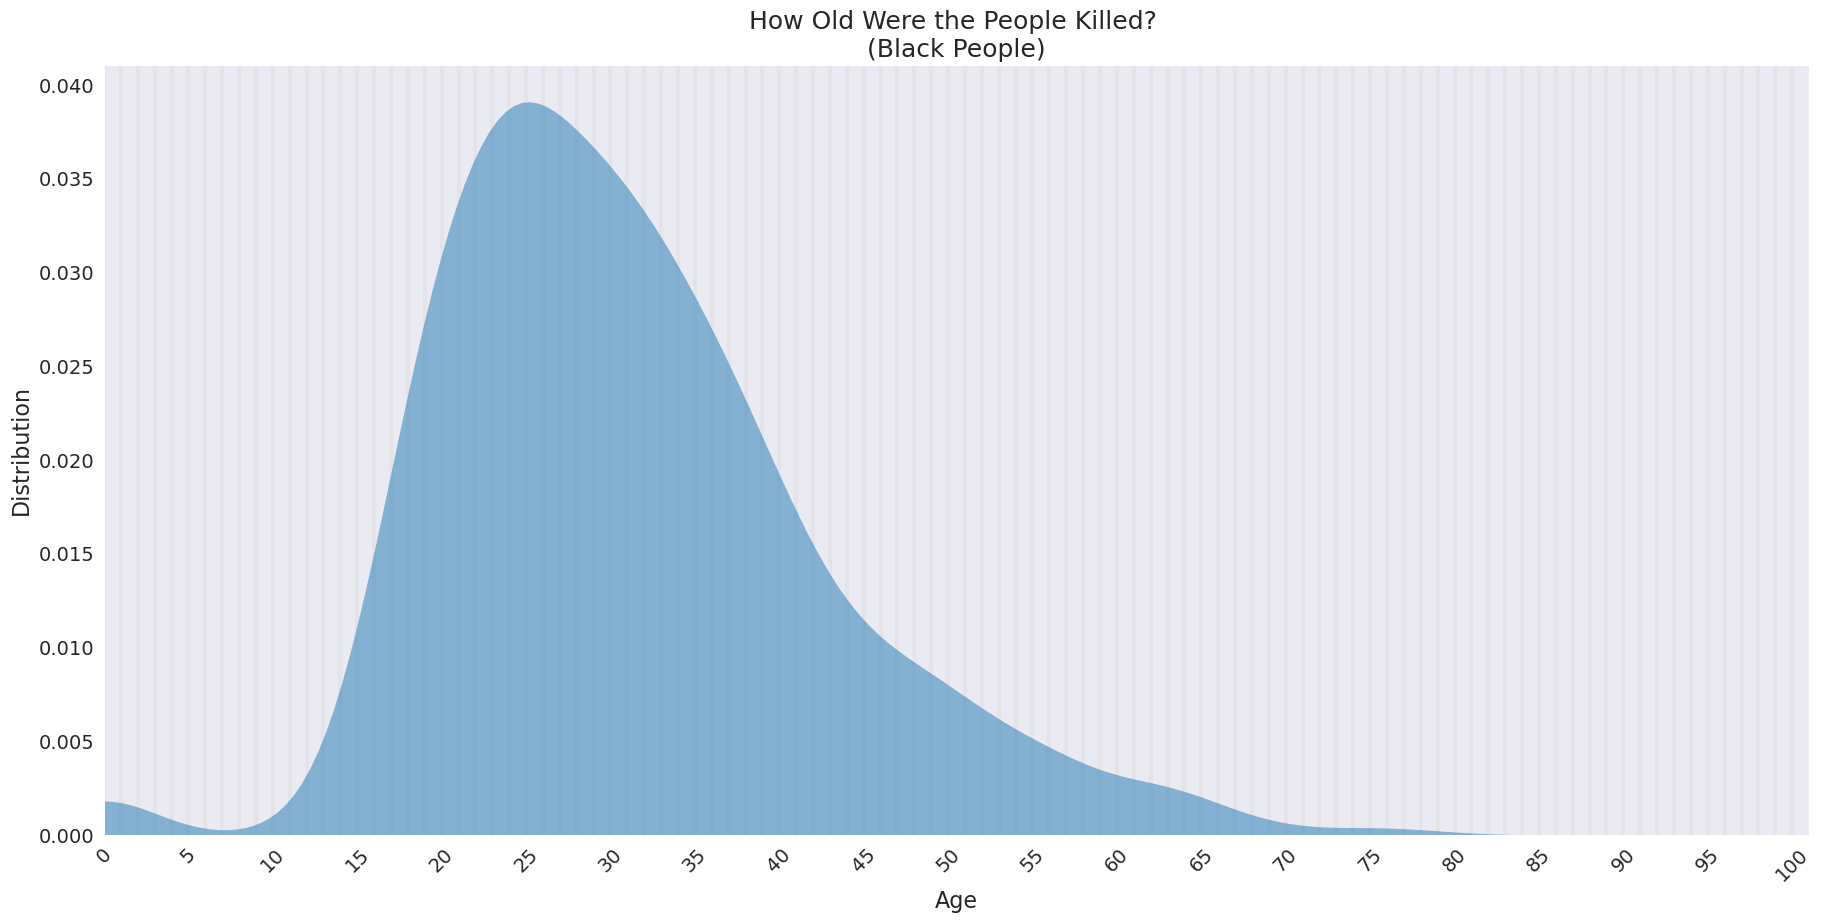

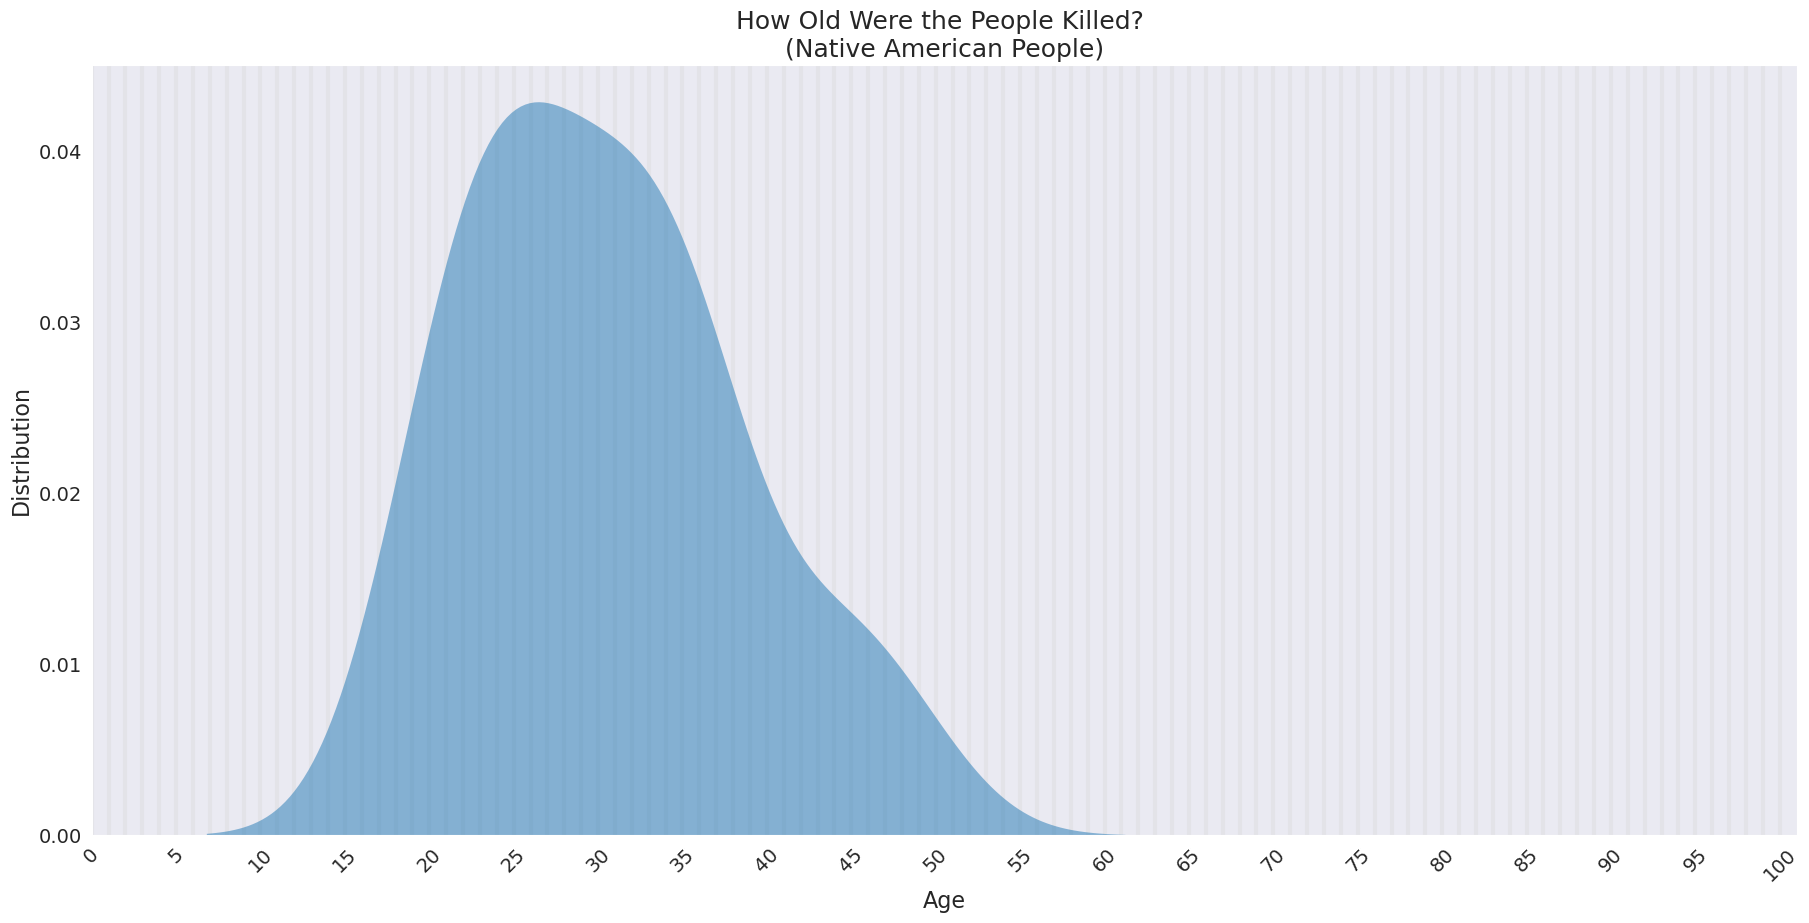

In [43]:
# Creating a KDE plot for each race
for race in df_fatalities.race.unique():
    # Dropping unknown values
    if race == "Unknown":
        pass
    else:
        new_df = df_fatalities[df_fatalities.race == race]
        # Setting chart layout
        with sns.axes_style("dark"):
            fig, ax = plt.subplots(figsize=(22, 10)) # Figure size
            sns.kdeplot(data=new_df, x="age", fill=True, common_norm=False,
               alpha=.5, linewidth=0) # Plot data
            plt.title(f"How Old Were the People Killed? \n({race} People)", fontsize=18) # Plot title
            # Setting up axes
            plt.xlabel("Age", fontsize=16)
            plt.ylabel("Distribution", fontsize=16)
            plt.xlim(0, 101)
            labels = [str(i) if i % 5 == 0 else '' for i in range(0, 101)]
            plt.xticks(range(0, 101, 1), labels, rotation=45, fontsize=14)
            plt.yticks(fontsize=14)
            # Setting up grid
            plt.grid(True, axis="x", alpha=0.3, linewidth=3, c="lightgray")



# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [44]:
fig = px.bar(
    data_frame=df_fatalities_by_race,
    x="race",
    y="count",
    height=700,
    title="Race of People Killed"
)

fig.update_layout(
    title_font_size=24,
    xaxis_title = "Race",
    yaxis_title = "Count",
    xaxis_title_font_size = 18,
    yaxis_title_font_size = 18,
    )

fig.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [45]:
pct_mental_illness = round(df_fatalities.signs_of_mental_illness.value_counts()[True] * 100 / df_fatalities.shape[0], 2)
print(f"{pct_mental_illness}% of people killed by the police had signs of mental illness.")

24.97% of people killed by the police had signs of mental illness.


In [46]:
fig = px.pie(
    df_fatalities,
    names="signs_of_mental_illness",
    title="Mental Illness and Police Killings"
)
fig.update_layout( legend=dict(title_text="Signs of Mental Illness"))
fig.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [47]:
top_10_killings_cities = df_fatalities.groupby(["state", "city"], as_index=False).size().sort_values("size", ascending=False)[:10]

In [48]:
fig = px.bar(
    top_10_killings_cities,
    x="city",
    y="size",
    title="Cities Where the Most Police Killings Take Place",
    height=700
)

fig.update_layout(
    title_font_size=24,
    xaxis_title = "City",
    yaxis_title = "Police Killings",
    xaxis_title_font_size = 18,
    yaxis_title_font_size = 18,
    )

fig.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

Rename Geographic area column:

In [49]:
df_share_race_city.rename(columns={"Geographic area": "Geographic_area"}, inplace=True)

Find the cities from top_10_killings_cities in the dangerous_cities_share dataframe:

In [50]:
dangerous_cities_share = []
for i in top_10_killings_cities.index:
    city = top_10_killings_cities.loc[i]
    q = f'Geographic_area == "{city.state}" and City.str.startswith("{city.city}")'
    dangerous_cities_share.append(df_share_race_city.query(q).head(1).index.to_list()[0])

In [51]:
dangerous_cities_share = df_share_race_city.loc[dangerous_cities_share].reset_index(drop=True)

In [52]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [53]:
top_10_killings_cities.reset_index(drop=True, inplace=True)

In [54]:
labels = dangerous_cities_share.columns[2:] # Race columns
# Setting up charts layout
specs = [[{"type":"domain"}, {"type":"domain"}]] * 5
fig = make_subplots(rows=5, cols=2, specs=specs, subplot_titles=top_10_killings_cities.city, vertical_spacing=0.03)
fig.update_layout(height=800, width=1000)
# Generating one subplot for each race
for i in range(10):
    j = (i // 2) + 1
    fig.add_trace(
        go.Pie(
            labels=labels, 
            values=dangerous_cities_share.loc[i][labels], 
            name=top_10_killings_cities.loc[i].city,
            marker_colors=px.colors.qualitative.T10
        ), 
        row=j, 
        col=(1 if not i % 2 else 2),

    )
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textinfo="none")
fig.update(layout_title_text='Police Killings by Race in Top 10 Cities',
           )
fig = go.Figure(fig)
fig.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [55]:
df_fatalities_by_state = df_fatalities.groupby("state", as_index=False).size().rename(columns={"size": "Killings"})

In [56]:
fig = px.choropleth(
    df_fatalities_by_state,
    locations="state",
    locationmode="USA-states", 
    scope="usa",
    color="Killings",
    color_continuous_scale = "Reds",
    title="Police Killings by US State",
    height=500
)
fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [57]:
# Rolling Avarage of date
df_fatalities_over_time = df_fatalities.groupby("date").size().rolling(window=30).sum().reset_index().rename(columns={0: "Killings"})

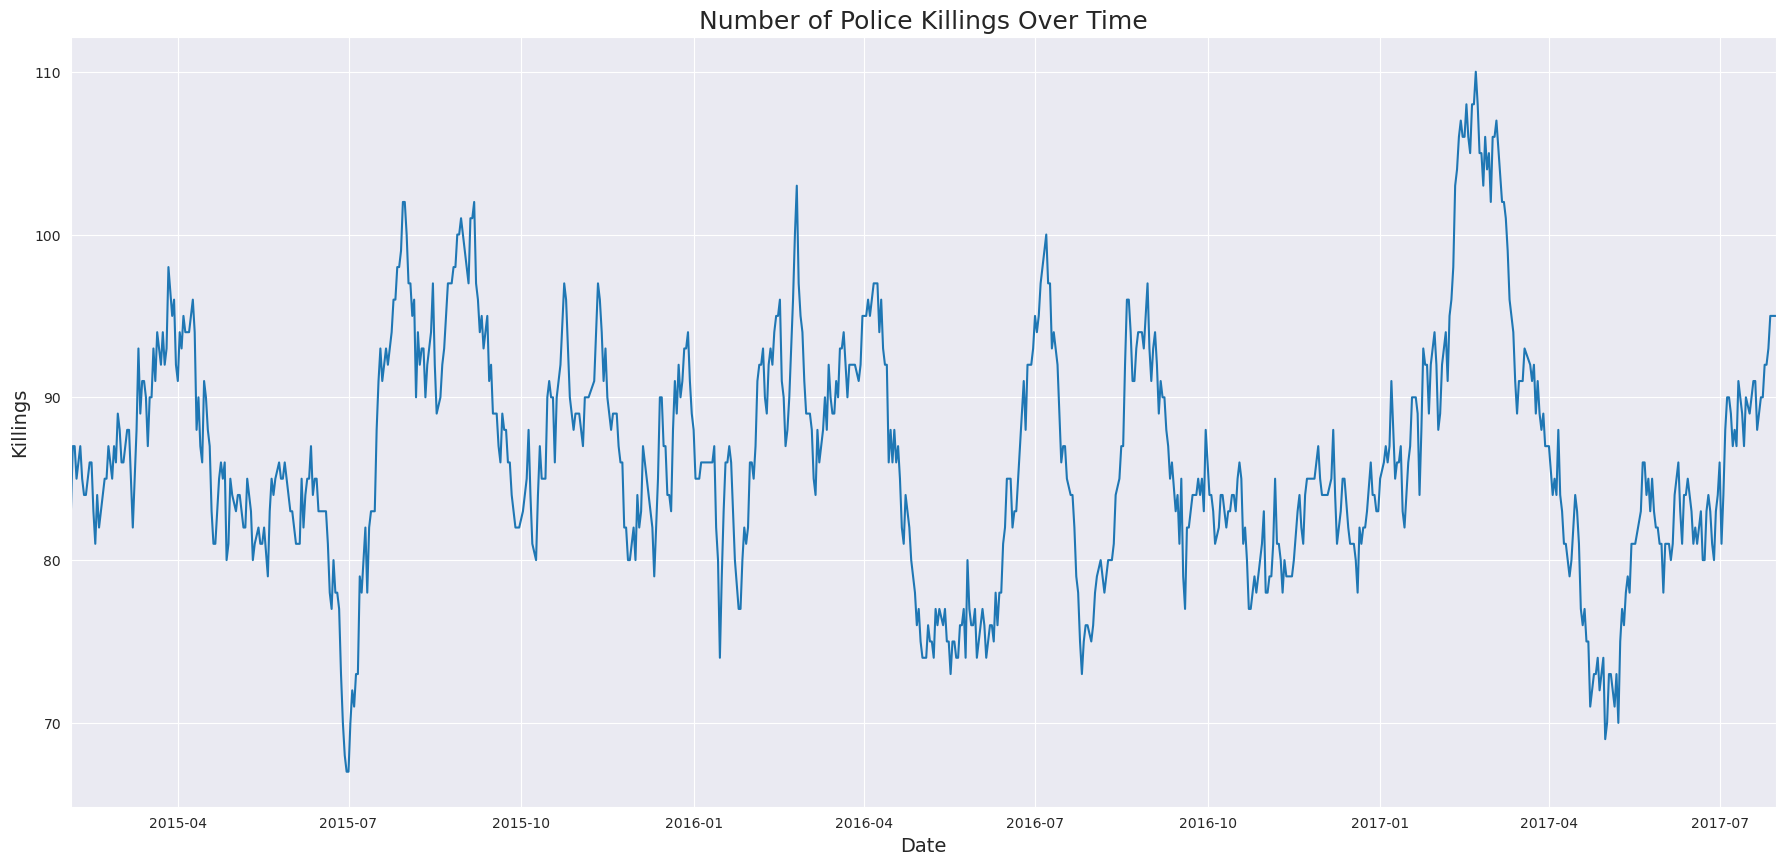

In [58]:
with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(22, 10))
    plt.title("Number of Police Killings Over Time", fontsize=18)
    plt.xlim(df_fatalities_over_time.loc[29].date, df_fatalities_over_time.date.max())
    sns.lineplot(df_fatalities_over_time, x="date", y="Killings")
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Killings", fontsize=14)

In [59]:
df_fatalities_over_time.dropna(inplace=True) # Drop NaN values

In [60]:
from matplotlib import dates
# Converting date to a numeric value
df_fatalities_over_time["date_num"] = dates.date2num(df_fatalities_over_time.date)

In [61]:
import matplotlib.dates as mdates
# Setting date locators 
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter("%Y")

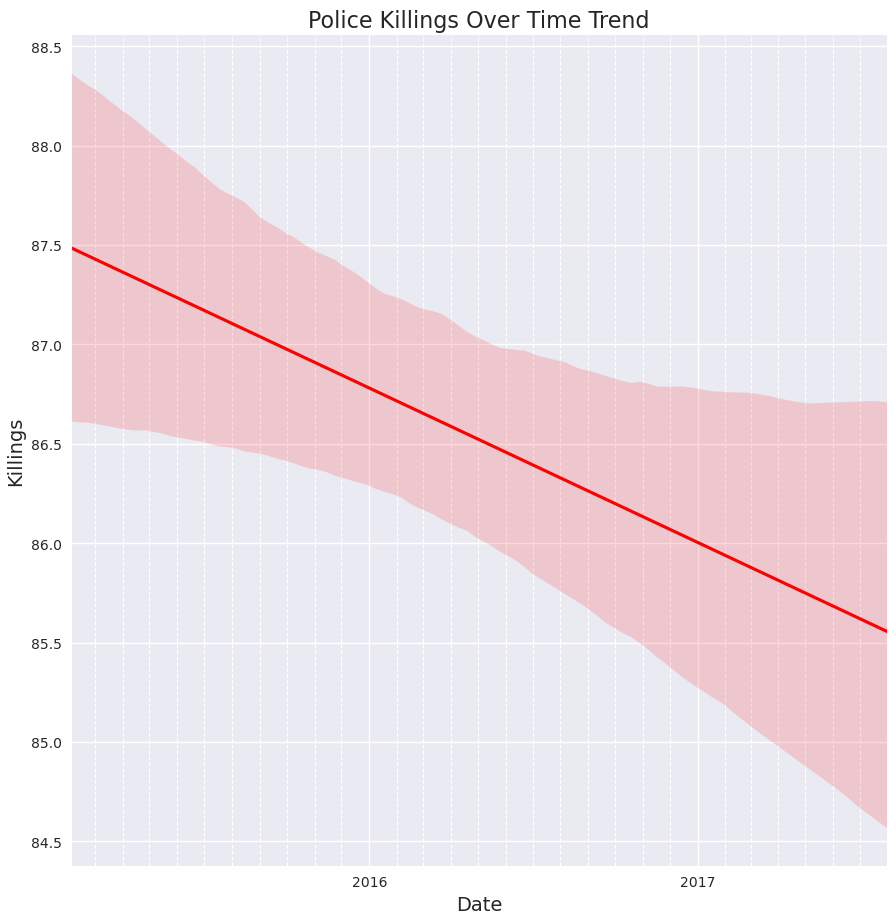

In [62]:
with sns.axes_style("dark"):
    sns.lmplot(data=df_fatalities_over_time, y="Killings", x="date_num", height=9, scatter=False, line_kws={"color": "red"})
    plt.title("Police Killings Over Time Trend", fontsize=16)

    ax = plt.gca()
    ax.grid(which="major", linewidth = 1)
    ax.grid(which="minor", linestyle="dashed")
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.xaxis.set_minor_locator(months)
    plt.xlim(df_fatalities_over_time.date.min(), df_fatalities_over_time.date.max())
    plt.ylabel("Killings", fontsize=14)
    plt.xlabel("Date", fontsize=14)